In [ ]:
import os
import shutil

print("🚀 Copying data from Drive to Local Disk (This speeds up training by 50x)...")

# 1. Define Source (Drive) and Destination (Local Colab)
source_dir = '/content/drive/MyDrive/NanoVision_Data'
local_dir = '/content/local_data'

# 2. Copy the folder
if not os.path.exists(local_dir):
    shutil.copytree(source_dir, local_dir)
    print("✅ Copy Complete! Data is now on fast local disk.")
else:
    print("⚡ Data already exists locally. Ready to go!")

🚀 Copying data from Drive to Local Disk (This speeds up training by 50x)...
✅ Copy Complete! Data is now on fast local disk.


📂 Loading Training Data...
Found 3114 images belonging to 3 classes.
📂 Loading Validation/Test Data...
Found 776 images belonging to 3 classes.
Classes: ['Biotic_Stress', 'Healthy', 'Zinc_Deficiency']
⚖️ Calculated Class Weights: {0: np.float64(1.4046008119079838), 1: np.float64(0.6411365040148239), 2: np.float64(1.373015873015873)}

🏗️ Building EfficientNetB0...

🚀 Phase 1: Training Head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5587 - loss: 0.9167 - val_accuracy: 0.7771 - val_loss: 0.5698
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8304 - loss: 0.4783 - val_accuracy: 0.8144 - val_loss: 0.4398
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8817 - loss: 0.3639 - val_accuracy: 0.8595 - val_loss: 0.3526
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8883 - loss: 0.3220 - val_accuracy: 0.8724 - val_loss: 0.3287
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8907 - loss: 0.3026 - val_accuracy: 0.8673 - val_loss: 0.3335
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9235 - loss: 0.2592 - val_accuracy: 0.8892 - val_loss: 0.2908
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9152 - loss: 0.2491 - val_accuracy: 0.8814 - val_loss: 0.3054
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9191 - loss: 0.2425 - val_accuracy: 0.9021 - va

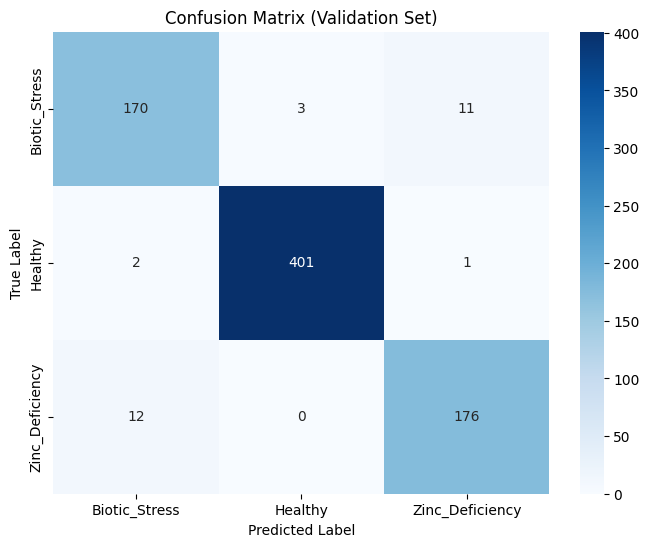


📜 Detailed Classification Report:
                 precision    recall  f1-score   support

  Biotic_Stress       0.92      0.92      0.92       184
        Healthy       0.99      0.99      0.99       404
Zinc_Deficiency       0.94      0.94      0.94       188

       accuracy                           0.96       776
      macro avg       0.95      0.95      0.95       776
   weighted avg       0.96      0.96      0.96       776


✅ Model Saved!


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. CONFIGURATION
DATA_DIR = '/content/local_data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE = 10


# 2. DATA GENERATORS (CORRECT SPLIT)

#validation_split to separate Train (80%) and Val (20%)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% reserved for testing
)

print("📂 Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

print("📂 Loading Validation/Test Data...")
val_generator = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False # Shuffle=False needed for Confusion Matrix
)

NUM_CLASSES = train_generator.num_classes
CLASS_NAMES = list(train_generator.class_indices.keys())
print("Classes:", CLASS_NAMES)

# ================================
# 3. CLASS WEIGHTS

train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print(f"⚖️ Calculated Class Weights: {class_weights_dict}")

# ================================
# 4. BUILD MODEL
# ================================
print("\n🏗️ Building EfficientNetB0...")
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# ================================
# 5. TRAINING (PHASE 1)
# ================================
print("\n🚀 Phase 1: Training Head...")
history_frozen = model.fit(
    train_generator,
    epochs=EPOCHS_FROZEN,
    validation_data=val_generator,
    class_weight=class_weights_dict, # Applied weights
    verbose=1
)

# ================================
# 6. FINE-TUNING (PHASE 2)
# ================================
print("\n🔧 Phase 2: Unfreezing & Fine-Tuning...")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

history_fine = model.fit(
    train_generator,
    epochs=EPOCHS_FINE,
    validation_data=val_generator,
    class_weight=class_weights_dict,
    verbose=1
)

# ================================
# 7. FINAL EVALUATION
# ================================
print("\n📊 Generating Research Metrics...")
# Predict on Validation Set (Honest Proxy)
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# A. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# B. Classification Report
print("\n📜 Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Save
model.save("/content/drive/MyDrive/NanoVision_Final_Ivy_Ready.h5")
print("\n✅ Model Saved!")

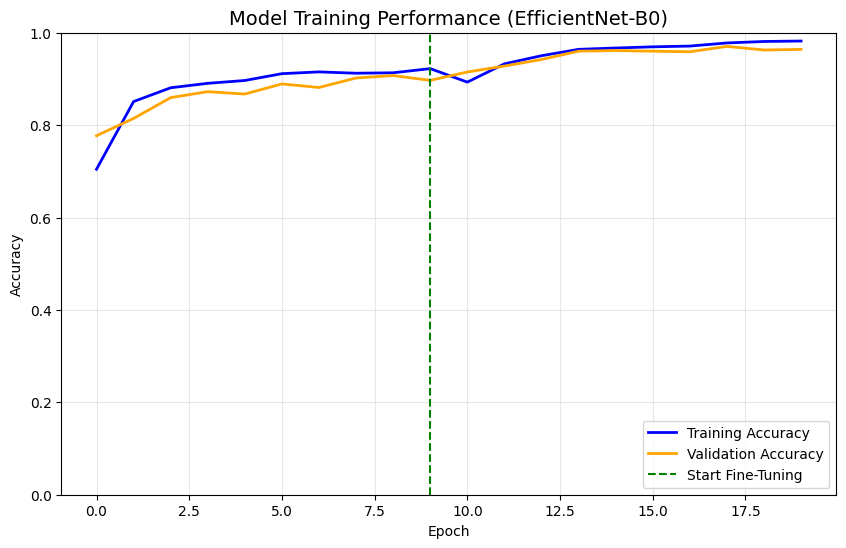

🏆 Final Validation Accuracy: 96.39%


In [ ]:
import matplotlib.pyplot as plt

# 1. COMBINE DATA FROM BOTH PHASES
# (We assume you have 'history_frozen' and 'history_fine' from the previous run)

# Accuracy
acc = history_frozen.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_frozen.history['val_accuracy'] + history_fine.history['val_accuracy']

# Loss
loss = history_frozen.history['loss'] + history_fine.history['loss']
val_loss = history_frozen.history['val_loss'] + history_fine.history['val_loss']

# 2. PLOT ACCURACY (This is "Figure 1")
plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', color='orange', linewidth=2)

# Add a vertical line to show where Fine-Tuning started
plt.axvline(x=9, label='Start Fine-Tuning', color='green', linestyle='--')

plt.title('Model Training Performance (EfficientNet-B0)', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0]) # Force scale to 0-100%

plt.show()

# 3. PRINT THE EXACT NUMBER
print(f"🏆 Final Validation Accuracy: {val_acc[-1]*100:.2f}%")